In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('C:/Data/wholesale.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [3]:
X = df.drop(columns = ['Channel', 'Region'])

In [ ]:
# Scale the features first — KMeans uses Euclidean distance, so unscaled features
# with large variance (e.g. Fresh in the thousands) dominate the clusters
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
cluster_range = range(1, 10)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(cluster_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method — Optimal Number of Clusters (Scaled Data)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

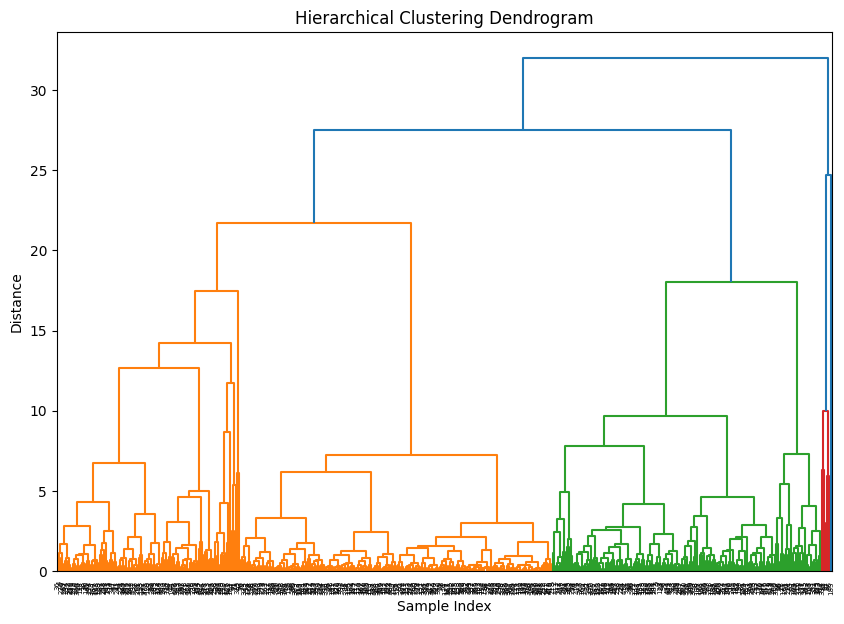

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import fcluster
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110})

feature_cols = list(X.columns)
K_BEST = 3  # from elbow method

# ── Easy: Cluster Profiles — Radar/Spider Chart ───────────────────────────────
kmeans = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
X_clustered = X.copy()
X_clustered['Cluster'] = cluster_labels

# Normalize cluster centers to [0,1] for radar readability
centers = kmeans.cluster_centers_   # in scaled space
centers_norm = (centers - centers.min(axis=0)) / (centers.max(axis=0) - centers.min(axis=0) + 1e-8)

angles = np.linspace(0, 2*np.pi, len(feature_cols), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': 'polar'})
colors_radar = ['#e74c3c','#3498db','#2ecc71','#f39c12']
for k in range(K_BEST):
    vals = centers_norm[k].tolist() + [centers_norm[k][0]]
    ax.plot(angles, vals, lw=2.5, color=colors_radar[k], label=f'Cluster {k}')
    ax.fill(angles, vals, alpha=0.18, color=colors_radar[k])
ax.set_thetagrids(np.degrees(angles[:-1]), feature_cols, fontsize=12)
ax.set_title(f'Wholesale Customer Cluster Profiles (K={K_BEST})\nRadar Chart of Normalized Spend per Category',
             fontsize=13, fontweight='bold', pad=25)
ax.legend(fontsize=11, loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout(); plt.show()

# ── Medium: PCA 2D Cluster Scatter ───────────────────────────────────────────
pca_cl = PCA(n_components=2)
X_pca = pca_cl.fit_transform(X_scaled)
ev = pca_cl.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 8))
for k in range(K_BEST):
    mask = cluster_labels == k
    ax.scatter(X_pca[mask,0], X_pca[mask,1], s=50, alpha=0.65,
               color=colors_radar[k], label=f'Cluster {k}  (n={mask.sum()})')
# Plot centroids in PCA space
centroids_pca = pca_cl.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:,0], centroids_pca[:,1], s=250, color='black',
           marker='*', zorder=5, label='Centroids')
ax.set_title(f'KMeans Clusters (K={K_BEST}) in PCA Space\n(PC1={ev[0]:.1%} + PC2={ev[1]:.1%} = {ev.sum():.1%} variance explained)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({ev[0]:.1%})'); ax.set_ylabel(f'PC2 ({ev[1]:.1%})')
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

# ── Medium: Cluster Spend Profile — Grouped Bar ───────────────────────────────
cluster_means = X_clustered.groupby('Cluster')[feature_cols].mean()
cluster_means_norm = cluster_means.div(cluster_means.max(axis=0), axis=1)

x_pos = np.arange(len(feature_cols))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 6))
for k in range(K_BEST):
    ax.bar(x_pos + k*width, cluster_means_norm.iloc[k], width=width,
           color=colors_radar[k], label=f'Cluster {k}', alpha=0.85, edgecolor='white')
ax.set_xticks(x_pos + width); ax.set_xticklabels(feature_cols, rotation=20, fontsize=11)
ax.set_title('Normalized Spend per Category by Cluster\n(relative to category maximum)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Normalized Spend'); ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

# ── Hard: Silhouette Score vs K ──────────────────────────────────────────────
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), sil_scores, 'o-', lw=2.5, color='#8e44ad', markersize=8)
axes[0].axvline(K_BEST, color='red', lw=1.8, linestyle='--', label=f'K={K_BEST} (chosen)')
axes[0].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K (number of clusters)'); axes[0].set_ylabel('Silhouette Score')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(list(cluster_range), wcss, 'o--', lw=2.5, color='#e74c3c', markersize=8)
axes[1].axvline(K_BEST, color='red', lw=1.8, linestyle='--', label=f'K={K_BEST}')
axes[1].set_title('Elbow Method (WCSS) vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('WCSS')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('Optimal K Selection: Silhouette + Elbow', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── Hard: Heatmap of Cluster Assignments from Hierarchical Clustering ─────────
hc_labels = fcluster(linked, t=K_BEST, criterion='maxclust') - 1

# Sort rows by hierarchical cluster
X_heat = pd.DataFrame(X_scaled, columns=feature_cols)
X_heat['HC_Cluster'] = hc_labels
X_heat_sorted = X_heat.sort_values('HC_Cluster').drop(columns='HC_Cluster')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(X_heat_sorted, ax=ax, cmap='RdBu_r', center=0,
            linewidths=0.1, linecolor='white', cbar_kws={'label': 'Std. deviations from mean'})
# Add cluster boundary lines
counts = np.cumsum([np.sum(hc_labels == k) for k in range(K_BEST)])
for c in counts[:-1]:
    ax.axhline(c, color='black', lw=2.5)
ax.set_title('Hierarchical Cluster Heatmap — All Customers (sorted by cluster)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Product Category'); ax.set_ylabel('Customer Index')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()